<a href="https://colab.research.google.com/github/Grzegorz-GG/DissertationPW/blob/main/Experiment14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import wandb
import joblib
import torchvision.transforms as transforms
from torchvision.transforms import v2

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import timm
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
gt_path = 'train_gt.csv'
wavelength_path = 'wavelengths.csv'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

output_dir = '/content/test_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/test.tar.gz -C {output_dir}

test/
test/77.npz
test/837.npz
test/189.npz
test/63.npz
test/823.npz
test/638.npz
test/610.npz
test/88.npz
test/176.npz
test/162.npz
test/604.npz
test/1145.npz
test/1151.npz
test/348.npz
test/374.npz
test/412.npz
test/406.npz
test/360.npz
test/599.npz
test/1019.npz
test/1031.npz
test/1025.npz
test/228.npz
test/200.npz
test/566.npz
test/572.npz
test/214.npz
test/943.npz
test/957.npz
test/758.npz
test/980.npz
test/994.npz
test/764.npz
test/770.npz
test/771.npz
test/765.npz
test/995.npz
test/981.npz
test/759.npz
test/956.npz
test/942.npz
test/573.npz
test/215.npz
test/201.npz
test/567.npz
test/229.npz
test/1024.npz
test/1030.npz
test/1018.npz
test/598.npz
test/407.npz
test/361.npz
test/375.npz
test/413.npz
test/349.npz
test/1150.npz
test/1144.npz
test/163.npz
test/605.npz
test/89.npz
test/611.npz
test/177.npz
test/639.npz
test/822.npz
test/62.npz
test/836.npz
test/76.npz
test/188.npz
test/60.npz
test/820.npz
test/74.npz
test/834.npz
test/48.npz
test/808.npz
test/149.npz
test/607.npz
test/

In [6]:
import os

output_dir = '/content/train_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/train.tar.gz -C {output_dir}

train/
train/77.npz
train/837.npz
train/189.npz
train/1409.npz
train/63.npz
train/823.npz
train/1347.npz
train/1421.npz
train/1435.npz
train/1353.npz
train/638.npz
train/610.npz
train/1384.npz
train/88.npz
train/176.npz
train/162.npz
train/1390.npz
train/604.npz
train/1179.npz
train/1623.npz
train/1145.npz
train/1151.npz
train/1637.npz
train/348.npz
train/374.npz
train/1186.npz
train/412.npz
train/406.npz
train/1192.npz
train/360.npz
train/599.npz
train/1019.npz
train/1031.npz
train/1025.npz
train/228.npz
train/200.npz
train/566.npz
train/572.npz
train/214.npz
train/943.npz
train/1569.npz
train/957.npz
train/1233.npz
train/1555.npz
train/1541.npz
train/1227.npz
train/758.npz
train/980.npz
train/994.npz
train/764.npz
train/1596.npz
train/1582.npz
train/770.npz
train/1583.npz
train/771.npz
train/765.npz
train/1597.npz
train/995.npz
train/981.npz
train/759.npz
train/1540.npz
train/1226.npz
train/1232.npz
train/1554.npz
train/956.npz
train/942.npz
train/1568.npz
train/573.npz
train/215.npz

In [7]:
gt_df = pd.read_csv(gt_path)
wavelength_df = pd.read_csv(wavelength_path)

In [92]:
def load_data(directory: str):
    data = []

    all_files = np.array(
        sorted(
            glob(os.path.join(directory, "*.npz")),
            key=lambda x: int(os.path.basename(x).replace(".npz", "")),
        )
    )

    for file_name in all_files:
        with np.load(file_name) as npz:
            raw_arr = np.ma.MaskedArray(data=npz['data'], mask=npz['mask'])
            img_tensor_raw = torch.as_tensor(raw_arr.data, dtype=torch.float)
            img_tensor_mask = ~torch.as_tensor(raw_arr.mask) # Revert mask: 0 is invalid, 1 is valid
            img_tensor_masked = torch.mul(img_tensor_raw, img_tensor_mask)
        data.append(img_tensor_masked)

    return data

In [93]:
def load_gt(file_path: str):
    """Load labels for train set from the ground truth file.
    Args:
        file_path (str): Path to the ground truth .csv file.
    Returns:
        [type]: 2D numpy array with soil properties levels
    """
    gt_file = pd.read_csv(file_path)
    labels = gt_file[["P", "K", "Mg", "pH"]].values
    return labels

In [173]:
X_train = load_data("/content/train_data/train")
y_train = load_gt("train_gt.csv")

In [209]:
# Collect all pixels for PCA
# =========================
def collect_pixels(data_list, max_pixels=10000000):
    """
    Flatten pixels from all patches for PCA, sampling to control memory usage.
    Samples pixels from each patch to ensure the total collected does not exceed max_pixels.
    """
    all_pixels = []
    # Estimate total pixels to determine sampling ratio
    total_potential_pixels = sum(arr.shape[1] * arr.shape[2] for arr in data_list)

    sampling_ratio = 1.0
    if total_potential_pixels > max_pixels:
        sampling_ratio = max_pixels / total_potential_pixels
        print(f"Sampling {sampling_ratio*100:.2f}% of pixels to stay within {max_pixels} limit.")

    for arr in data_list:
        #data = arr.filled(0) if isinstance(arr, np.ma.MaskedArray) else arr
        data = np.transpose(arr, (1, 2, 0))  # H, W, C
        pixels = data.reshape(-1, data.shape[-1]) # (H*W, C)

        if sampling_ratio < 1.0 and pixels.shape[0] > 0:
            num_pixels_to_sample = int(pixels.shape[0] * sampling_ratio)
            # Ensure we don't try to sample more pixels than available
            num_pixels_to_sample = max(1, min(num_pixels_to_sample, pixels.shape[0]))
            idx = np.random.choice(pixels.shape[0], num_pixels_to_sample, replace=False)
            all_pixels.append(pixels[idx])
        else:
            all_pixels.append(pixels)

    if not all_pixels:
        return np.empty((0, data_list[0].shape[0])) # Return empty array with correct feature dim

    X = np.vstack(all_pixels)
    return X


In [210]:
def transform_patches(data_list, scaler, pca):
    """
    Transforms a list of data patches using a fitted StandardScaler and PCA.

    Args:
        data_list (list): A list of torch.Tensor or numpy.ndarray objects,
                          each representing a hyperspectral image patch (C, H, W).
        scaler (StandardScaler): A fitted StandardScaler object.
        pca (PCA): A fitted PCA object.

    Returns:
        list: A list of transformed patches, where each patch is a torch.Tensor
              with reduced dimensions (n_components, H, W).
    """
    transformed_list = []
    for arr in data_list:
        #data = arr.filled(0) if isinstance(arr, np.ma.MaskedArray) else arr
        data = np.transpose(arr, (1, 2, 0))  # H, W, C
        H, W, C = data.shape
        pixels = data.reshape(-1, C)
        pixels_scaled = scaler.transform(pixels)
        pixels_pca = pca.transform(pixels_scaled)
        data_pca = pixels_pca.reshape(H, W, -1)

        tensor_patch = torch.from_numpy(np.transpose(data_pca, (2, 0, 1)).astype(np.float32))

        # # ---- Resize to fixed size ----
        # tensor_patch = F.interpolate(
        #     tensor_patch.unsqueeze(0),
        #     size=(224, 224),
        #     mode='bilinear',
        #     align_corners=False
        # ).squeeze(0)

        transformed_list.append(tensor_patch)
    return transformed_list

In [42]:
# # -----------------------
# # Split into train, val, test
# # -----------------------

# # First, split off test set (20%)
# X_temp, X_test, y_temp, y_test = train_test_split(
#     X_train, y_train, test_size=0.2, random_state=42
# )

# # Then, split remaining 80% into train/val
# X_train_final, X_val, y_train_final, y_val = train_test_split(
#     X_temp, y_temp, test_size=0.2, random_state=42
# )

# print(f"Train patches: {len(X_train_final)}")
# print(f"Validation patches: {len(X_val)}")
# print(f"Test patches: {len(X_test)}")

In [211]:
# -----------------------
# Split into train, val, test
# -----------------------

# Create an array of indices for X_train
original_indices = np.arange(len(X_train))

# First, split off test set (20%)
X_temp, X_test, y_temp, y_test, temp_indices, test_indices = train_test_split(
    X_train, y_train, original_indices, test_size=0.2, random_state=10
)

# Then, split remaining 80% into train/val
X_train_final, X_val, y_train_final, y_val, train_indices, val_indices = train_test_split(
    X_temp, y_temp, temp_indices, test_size=0.2, random_state=10
)

print(f"Train patches: {len(X_train_final)}")
print(f"Validation patches: {len(X_val)}")
print(f"Test patches: {len(X_test)}")

Train patches: 1108
Validation patches: 277
Test patches: 347


In [ ]:
# # Load PCA instead of refitting
# pca = joblib.load("pca_hyperspectral.pkl")
# print("PCA loaded from file")

# scaler = joblib.load("scaler_hyperspectral.pkl")
# print("Scaler loaded from file")

In [241]:
# Fit PCA on training pixels (as before)
X_pixels_train = collect_pixels(X_train_final)

# ------------------------
# Normalize training pixels
# ------------------------
scaler = StandardScaler()
X_pixels_train_scaled = scaler.fit_transform(X_pixels_train)

# Save scaler for later
joblib.dump(scaler, "scaler_hyperspectral.pkl")
print("Scaler saved.")

# Set n_components to match the model's in_channels
n_components = 3
pca = PCA(n_components=n_components)
pca.fit(X_pixels_train_scaled)

# Save PCA
joblib.dump(pca, "pca_hyperspectral.pkl")
print("PCA saved")

Scaler saved.
PCA saved


In [242]:
X_train_pca = transform_patches(X_train_final, scaler, pca)
X_val_pca   = transform_patches(X_val, scaler, pca)
X_test_pca  = transform_patches(X_test, scaler, pca)

In [243]:
# -------------------------------
# Scale labels
# -------------------------------
scaler_y = StandardScaler()
y_train_final_scaled = scaler_y.fit_transform(y_train_final)
y_val_scaled   = scaler_y.transform(y_val)
y_test_scaled  = scaler_y.transform(y_test)
joblib.dump(scaler_y, "scaler_labels.pkl")
print("Label scaler saved.")

Label scaler saved.


In [244]:
class NPZDataset(Dataset):
    def __init__(self, tensor_list, labels, augment=True, size=(224,224)):
        self.tensor_list = tensor_list
        self.labels = labels
        self.augment = augment
        self.size = size

        self.transform_aug = v2.Compose([
            v2.Resize((224, 224)),
            v2.RandomHorizontalFlip(p=0.5),
            v2.GaussianNoise(mean=0.0, sigma=0.03),
        ])

        self.transform_basic = v2.Compose([
            v2.Resize((224, 224)),
        ])


    def __len__(self):
        return len(self.tensor_list)

    def __getitem__(self, idx):
        x = self.tensor_list[idx]

        # # ---- Unconditionally resize to fixed size first ----
        # # This ensures all tensors are of a consistent size before augmentation
        # # and before being passed to the DataLoader's collate_fn.
        # if x.shape[1] != self.size[0] or x.shape[2] != self.size[1]:
        #     x = F.interpolate(
        #         x.unsqueeze(0),  # add batch dim -> (1, C, H, W)
        #         size=self.size,
        #         mode='bilinear',
        #         align_corners=False
        #     ).squeeze(0)       # remove batch dim -> (C, H, W)

        # ---- Apply augmentation ----
        if self.augment:
            x = self.transform_aug(x)
        else:
            x = self.transform_basic(x)

        # ---- Per-channel normalization for CNN ----
        x = (x - x.mean(dim=(1,2), keepdim=True)) / (x.std(dim=(1,2), keepdim=True) + 1e-6)

        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

In [245]:
# -----------------------
# Create Dataset and DataLoader
# -----------------------

train_dataset = NPZDataset(X_train_pca, y_train_final_scaled, augment=True)
val_dataset   = NPZDataset(X_val_pca, y_val_scaled, augment=False)
test_dataset  = NPZDataset(X_test_pca, y_test_scaled, augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [246]:
class HyperspectralRegressor(nn.Module):
    def __init__(self, in_channels=20, n_outputs=4, backbone_name="efficientnet_b0", pretrained=False):
        """
        Hyperspectral regression model using EfficientNet backbone from timm.
        Args:
            in_channels (int): Number of input channels (after PCA)
            n_outputs (int): Number of regression targets (e.g., 4)
            backbone_name (str): EfficientNet variant from timm
            pretrained (bool): Use ImageNet weights
        """
        super().__init__()

        # Create backbone
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            in_chans=in_channels,
            num_classes=0,      # No classifier, we'll add our own head
        )

        # Feature dimension after backbone
        if hasattr(self.backbone, "num_features"):
            feat_dim = self.backbone.num_features
        else:
            feat_dim = self.backbone.fc.in_features  # fallback

        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, n_outputs)
        )

    def forward(self, x):
        # x: (B, in_channels, H, W)
        features = self.backbone(x)  # backbone outputs features (B, feat_dim)
        out = self.regressor(features)  # (B, n_outputs)
        return out

Test overfitting on one batch

In [247]:
train_data_single_batch = next(iter(train_loader))

In [248]:
train_data_single_batch[0].shape

torch.Size([16, 3, 224, 224])

In [249]:
train_data_single_batch[1].shape

torch.Size([16, 4])

In [251]:
# Re-initialize a fresh model for overfitting
model_overfit = HyperspectralRegressor(
    in_channels=3,   # PCA-reduced channels
    n_outputs=4,      # P, K, Mg, pH
    backbone_name="efficientnet_b2",
    pretrained=False  # Use pre-trained weights
)
model_overfit = model_overfit.to(device)

# Define optimizer and criterion for overfitting
optimizer_overfit = optim.AdamW(model_overfit.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_overfit = nn.MSELoss()

# Extract the single batch
x_single, y_single = train_data_single_batch
x_single, y_single = x_single.to(device), y_single.to(device)

# Overfitting loop
overfit_epochs = 500 # A high number of epochs to ensure overfitting
print(f"\n--- Starting Overfitting on Single Batch for {overfit_epochs} epochs ---")

for epoch_overfit in range(overfit_epochs):
    model_overfit.train()
    optimizer_overfit.zero_grad()

    outputs_overfit = model_overfit(x_single)
    loss_overfit = criterion_overfit(outputs_overfit, y_single)

    loss_overfit.backward()
    optimizer_overfit.step()

    if (epoch_overfit + 1) % 10 == 0 or epoch_overfit == 0:
        print(f"Overfit Epoch {epoch_overfit+1}/{overfit_epochs} - Loss: {loss_overfit.item():.6f}")

print("--- Overfitting complete ---")


--- Starting Overfitting on Single Batch for 500 epochs ---
Overfit Epoch 1/500 - Loss: 1.435782
Overfit Epoch 10/500 - Loss: 0.851284
Overfit Epoch 20/500 - Loss: 0.122083
Overfit Epoch 30/500 - Loss: 0.085883
Overfit Epoch 40/500 - Loss: 0.066991
Overfit Epoch 50/500 - Loss: 0.051156
Overfit Epoch 60/500 - Loss: 0.037208
Overfit Epoch 70/500 - Loss: 0.030057
Overfit Epoch 80/500 - Loss: 0.051917
Overfit Epoch 90/500 - Loss: 0.032782
Overfit Epoch 100/500 - Loss: 0.033635
Overfit Epoch 110/500 - Loss: 0.025215
Overfit Epoch 120/500 - Loss: 0.056904
Overfit Epoch 130/500 - Loss: 0.046361
Overfit Epoch 140/500 - Loss: 0.031255
Overfit Epoch 150/500 - Loss: 0.016859
Overfit Epoch 160/500 - Loss: 0.047801
Overfit Epoch 170/500 - Loss: 0.025848
Overfit Epoch 180/500 - Loss: 0.029616
Overfit Epoch 190/500 - Loss: 0.027025
Overfit Epoch 200/500 - Loss: 0.025947
Overfit Epoch 210/500 - Loss: 0.047679
Overfit Epoch 220/500 - Loss: 0.041999
Overfit Epoch 230/500 - Loss: 0.046174
Overfit Epoch 

In [252]:
print('\n--- Model Overfit Predictions vs. True Values ---')
model_overfit.eval() # Set model to evaluation mode

with torch.no_grad():
    outputs_single_batch = model_overfit(x_single)

print("Predictions:")
print(outputs_single_batch.cpu().numpy())
print("\nTrue Values:")
print(y_single.cpu().numpy())


--- Model Overfit Predictions vs. True Values ---
Predictions:
[[-0.34920487  0.3232997   0.53166765  0.06234859]
 [ 1.2770376   2.2973976   0.7452625   0.46865904]
 [-0.2734036  -0.35373786 -0.4670733   1.2813894 ]
 [ 0.5053067  -0.9293388  -0.5328581  -0.35430652]
 [-0.39118966 -0.6771729   0.04190472 -1.6251024 ]
 [-0.5053796  -0.4931972  -2.0339847   1.8055315 ]
 [-0.9205188  -1.015467    0.6518694  -3.0185192 ]
 [ 1.3175675  -0.25167423  0.54197973  0.8260505 ]
 [ 0.27405113 -0.47808263 -0.11539026  0.03719554]
 [-0.58934224 -1.0234307  -0.5746552   0.8143837 ]
 [ 0.03650484  1.4944656   1.0143437   0.04216714]
 [-0.83426917 -0.38654578 -0.6866442   0.03788082]
 [-0.45372388  0.04547898 -1.9168291   0.6804513 ]
 [ 2.4640641   3.4968507   3.5223954   1.5286742 ]
 [ 1.0349699   2.8869755  -0.28208822  1.9080695 ]
 [-0.12824601 -0.9092743  -1.0359479   0.34865102]]

True Values:
[[-0.38219947  0.2916729   0.526517    0.06302792]
 [ 1.2287934   2.1745183   0.6979167   0.44652563]
 [-

In [253]:
# Load the label scaler
scaler_y = joblib.load("scaler_labels.pkl")
print("Label scaler loaded.")

print('\n--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---')
# Inverse transform predictions and true values
unscaled_predictions = scaler_y.inverse_transform(outputs_single_batch.cpu().numpy())
unscaled_true_values = scaler_y.inverse_transform(y_single.cpu().numpy())

print("Unscaled Predictions:")
print(unscaled_predictions)
print("\nUnscaled True Values:")
print(unscaled_true_values)

Label scaler loaded.

--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---
Unscaled Predictions:
[[ 59.570797  247.96529   182.21036     6.799823 ]
 [107.41948   370.6357    190.93361     6.9057713]
 [ 61.801083  205.89418   141.42155     7.1176972]
 [ 84.71296   170.12634   138.7349      6.691177 ]
 [ 58.335484  185.79594   162.20833     6.359807 ]
 [ 54.97569   197.22818    77.42856     7.254371 ]
 [ 42.761112  164.77434   187.11942     5.996463 ]
 [108.611984  212.23642   182.6315      6.998964 ]
 [ 77.90876   198.1674    155.78436     6.793264 ]
 [ 52.50527   164.27948   137.0279      6.9959216]
 [ 70.91947   320.74152   201.92294     6.7945604]
 [ 45.29882   203.8555    132.45424     6.7934427]
 [ 56.49555   230.7015     82.21322     6.960998 ]
 [142.34518   445.1697    304.35233     7.1821785]
 [100.29716   407.27206   148.9764      7.281109 ]
 [ 66.07204   171.37315   118.18859     6.8744783]]

Unscaled True Values:
[[ 58.6      246.       182.         6.8     ]
 

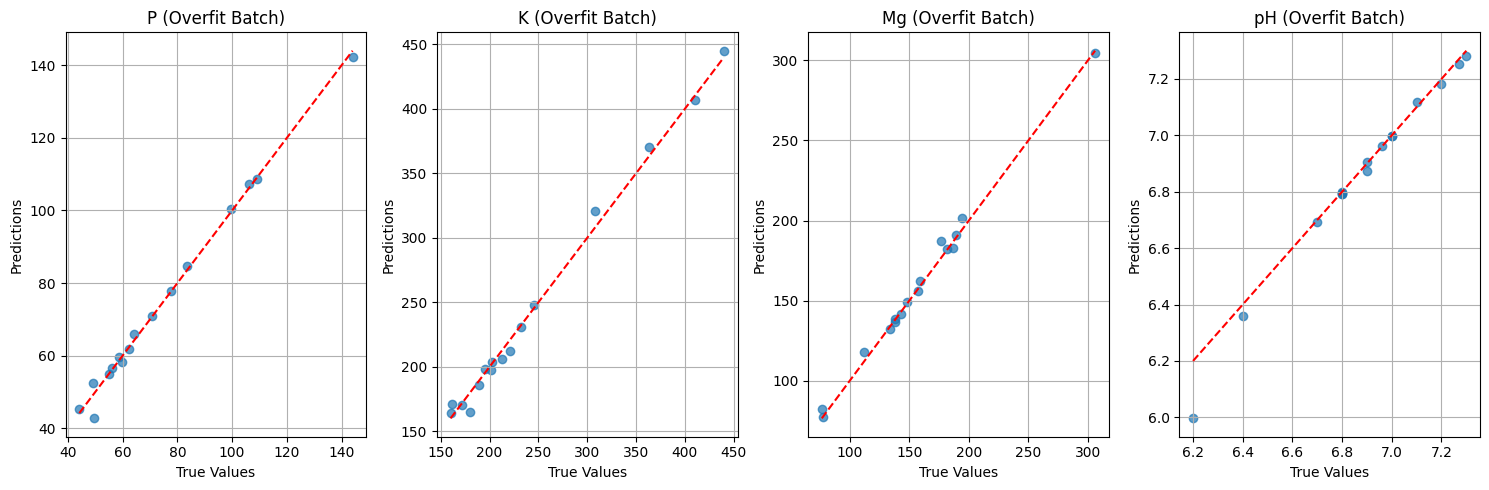

In [254]:

plt.figure(figsize=(15, 5))

metrics = ['P', 'K', 'Mg', 'pH']
for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i + 1) # 1 row, 4 columns
    plt.scatter(unscaled_true_values[:, i], unscaled_predictions[:, i], alpha=0.7)
    plt.plot([min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             [min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             'r--') # Red dashed line for ideal prediction
    plt.title(f'{metric} (Overfit Batch)')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.grid(True)

plt.tight_layout()
plt.show()


Learning loop

In [255]:

# ----- Model -----
model = HyperspectralRegressor(
    in_channels=3,   # PCA-reduced channels
    n_outputs=4,      # P, K, Mg, pH
    backbone_name="efficientnet_b2",
    pretrained=False
)

model = model.to(device);

# ----- Optimizer -----
optimizer = optim.AdamW([
    {"params": model.backbone.parameters(), "lr": 5e-5},
    {"params": model.regressor.parameters(), "lr": 2e-4},  # ↓ key fix
], weight_decay=1e-4)

# ----- Loss -----
criterion = nn.MSELoss()

# ----- Scheduler -----
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=5,
    min_lr=1e-6
)

# ----- Hyperparameters -----
epochs = 120
patience = 20  # early stopping patience
warmup_epochs = 6 # Number of epochs for warm-up

# ----- Initialize wandb -----
# Initializing Weights & Biases for experiment tracking.
wandb.init(
    project="hyperview_challenge efficientnet_b2 (no pretrained encoder), warm up phase and gradient clipping added, 10M pixels rand pca",
    config={
        "learning_rate_backbone": 5e-5,
        "learning_rate_head": 2e-4, # Corrected to match optimizer
        "epochs": epochs,
        "batch_size": 16,
        "optimizer": "AdamW",
        "criterion": "MSELoss",
        "backbone": "efficientnet_b2",
        "pca_components": 3, # Consistent with the new n_components
        "scheduler": "ReduceLROnPlateau",
        "scheduler_factor": 0.3,
        "scheduler_patience": 5,
        "min_lr": 1e-6,
        "warmup_epochs": warmup_epochs # Added warm-up epochs to config
    }
)
# Log a note to wandb about this run's configuration
wandb.run.log({"note": "This run uses an efficientnet_b2 backbone without pre-trained weights, with a warm-up phase for the learning rate, and PCA applied to 10M pixels randomly sampled pixels from the training data. 3 PCA components used. Gradient clipping added."})


In [256]:
# ----- Training with early stopping -----
best_val_loss = float('inf')
counter = 0

# Store initial learning rates for warm-up
initial_lr_backbone = optimizer.param_groups[0]['lr']
initial_lr_head = optimizer.param_groups[1]['lr']

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    # --- Warm-up logic ---
    if epoch < warmup_epochs:
        warmup_factor = (epoch + 1) / warmup_epochs
        for i, param_group in enumerate(optimizer.param_groups):
            if i == 0: # Backbone
                param_group['lr'] = initial_lr_backbone * warmup_factor
            else: # Regressor Head
                param_group['lr'] = initial_lr_head * warmup_factor

    for x, y in loop:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_loader)

    # ----- Validation -----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val_batch, y_val_batch in val_loader:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
            val_preds = model(X_val_batch)
            val_loss += criterion(val_preds, y_val_batch).item()
    val_loss /= len(val_loader)

    # Get current learning rates for logging
    current_lr_backbone = optimizer.param_groups[0]['lr']
    current_lr_head = optimizer.param_groups[1]['lr']

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - backbone LR: {current_lr_backbone:.6f} - head LR: {current_lr_head:.6f}")

    # ----- Log to wandb -----
    wandb.log({"train_loss": train_loss, "val_loss": val_loss, "epoch": epoch, "learning_rate_backbone": current_lr_backbone, "learning_rate_head": current_lr_head})

    # ----- Scheduler step (only after warm-up) -----
    if epoch >= warmup_epochs - 1: # Apply scheduler after warm-up finishes
        scheduler.step(val_loss)

    # ----- Early stopping -----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_hyperspectral_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# ----- Load best model -----
model.load_state_dict(torch.load("best_hyperspectral_model.pth"))

# ----- Finish wandb -----
wandb.finish()

Epoch 1/120 - Train Loss: 1.0093 - Val Loss: 0.9247 - backbone LR: 0.000008 - head LR: 0.000033


Epoch 2/120 - Train Loss: 1.0232 - Val Loss: 0.9203 - backbone LR: 0.000017 - head LR: 0.000067


Epoch 3/120 - Train Loss: 0.9817 - Val Loss: 0.9363 - backbone LR: 0.000025 - head LR: 0.000100


Epoch 4/120 - Train Loss: 0.9888 - Val Loss: 0.9400 - backbone LR: 0.000033 - head LR: 0.000133


Epoch 5/120 - Train Loss: 0.9860 - Val Loss: 0.9474 - backbone LR: 0.000042 - head LR: 0.000167


...

Epoch 25/120 - Train Loss: 0.8914 - Val Loss: 0.9417 - backbone LR: 0.000005 - head LR: 0.000018


Epoch 26/120 - Train Loss: 0.8982 - Val Loss: 0.9366 - backbone LR: 0.000005 - head LR: 0.000018


Epoch 27/120 - Train Loss: 0.8901 - Val Loss: 0.9348 - backbone LR: 0.000001 - head LR: 0.000005


Epoch 28/120 - Train Loss: 0.8881 - Val Loss: 0.9386 - backbone LR: 0.000001 - head LR: 0.000005
Early stopping triggered at epoch 28


epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
learning_rate_backbone,▂▃▄▆▇█████████▃▃▃▃▃▃▁▁▁▁▁▁▁▁
learning_rate_head,▂▃▄▆▇█████████▃▃▃▃▃▃▁▁▁▁▁▁▁▁
train_loss,▇█▆▆▆▅▅▅▅▄▄▅▄▃▃▃▂▃▃▂▂▁▂▁▁▂▁▁
val_loss,▂▂▃▄▄▃▁▁▂▄▅█▃▅▃▃▄▃▂▃▃▃▄▄▄▃▃▄
epoch,27
learning_rate_backbone,0.0
learning_rate_head,1e-05
note,This run uses an eff...
train_loss,0.88812
val_loss,0.93855


Evaluate results in comparision to the Baseline Regressor.

In [257]:
class BaselineRegressor:
    """
    Baseline regressor, which calculates the mean value of the target from the training
    data and returns it for each testing sample.
    """
    def __init__(self):
        self.mean = 0

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        self.mean = np.mean(y_train, axis=0)
        self.classes_count = y_train.shape[1]
        return self

    def predict(self, X_test: np.ndarray):
        return np.full((len(X_test), self.classes_count), self.mean)


class SpectralCurveFiltering():
    """
    Create a histogram (a spectral curve) of a 3D cube, using the merge_function
    to aggregate all pixels within one band. The return array will have
    the shape of [CHANNELS_COUNT]
    """

    def __init__(self, merge_function = np.mean):
        self.merge_function = merge_function

    def __call__(self, sample: np.ndarray):
        return self.merge_function(sample, axis=(1, 2))

In [258]:
def evaluate_dl_model(model, test_loader, scaler_y, device):
    """Evaluates the deep learning model on the test dataset."""
    model.eval()
    test_predictions_scaled = []
    y_true_scaled = [] # To collect the true scaled labels from the DataLoader

    with torch.no_grad():
        for X_batch_test, y_batch_true_scaled in test_loader:
            X_batch_test = X_batch_test.to(device)
            preds_batch = model(X_batch_test)
            test_predictions_scaled.append(preds_batch.cpu().numpy())
            y_true_scaled.append(y_batch_true_scaled.cpu().numpy())

    y_test_scaled_pred = np.vstack(test_predictions_scaled)
    y_test_scaled_true = np.vstack(y_true_scaled)

    # Inverse transform predictions and true values
    y_test_pred = scaler_y.inverse_transform(y_test_scaled_pred)
    y_test_true_from_loader = scaler_y.inverse_transform(y_test_scaled_true)

    model_mse_targets = np.mean((y_test_true_from_loader - y_test_pred)**2, axis=0)
    return y_test_pred, y_test_true_from_loader, model_mse_targets

def evaluate_baseline_regressor(baseline_regressor, X_test_filtered, y_test_true):
    """Evaluates the baseline regressor on the test dataset."""
    baseline_preds_test = baseline_regressor.predict(X_test_filtered)
    baseline_mse_targets = np.mean((y_test_true - baseline_preds_test)**2, axis=0)
    return baseline_preds_test, baseline_mse_targets

def calculate_and_print_results(model_mse_targets, baseline_mse_targets, y_test_true, y_test_pred, baseline_preds_test):
    """Calculates and prints the challenge score and per-target comparison, and plots results."""
    challenge_score = np.mean(model_mse_targets / baseline_mse_targets)

    target_names = ["P", "K", "Mg", "pH"]
    print("Per-target comparison (on local test set from training data):")
    for i, name in enumerate(target_names):
        print(f"{name}: Model MSE = {model_mse_targets[i]:.4f}, Baseline MSE = {baseline_mse_targets[i]:.4f}, Normalized = {model_mse_targets[i]/baseline_mse_targets[i]:.4f}")

    print(f"\nChallenge normalized score (lower is better, on local test set): {challenge_score:.4f}")

    # Plotting
    plt.figure(figsize=(15, 5))
    for i, metric in enumerate(target_names):
        plt.subplot(1, 4, i + 1)
        plt.scatter(y_test_true[:, i], y_test_pred[:, i], alpha=0.7, label='DL Model Predictions')
        plt.scatter(y_test_true[:, i], baseline_preds_test[:, i], alpha=0.7, label='Baseline Predictions', marker='x')
        min_val = min(y_test_true[:, i].min(), y_test_pred[:, i].min(), baseline_preds_test[:, i].min())
        max_val = max(y_test_true[:, i].max(), y_test_pred[:, i].max(), baseline_preds_test[:, i].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Prediction')
        plt.title(f'{metric} Predictions')
        plt.xlabel('True Values')
        plt.ylabel('Predictions')
        plt.grid(True)
        plt.legend()
    plt.tight_layout()
    plt.show()

In [259]:
# Get true y values from the local test dataset (inverse-scaled)
y_test_scaled_true = np.array([test_dataset[i][1].numpy() for i in range(len(test_dataset))])
y_test_true = scaler_y.inverse_transform(y_test_scaled_true)

In [260]:
# We need the original unscaled, non-PCA data for the baseline regressor
X_test_nonpca = [X_train[i] for i in test_indices]

# We need to apply SpectralCurveFiltering to the original X_test_nonpca for the baseline regressor
filtering = SpectralCurveFiltering()
X_test_filtered = np.array([filtering(cube.cpu().numpy()) for cube in X_test_nonpca])

# Train a new baseline regressor on the combined training and validation splits
# Combine train and validation indices
combined_train_val_indices = train_indices.tolist() + val_indices.tolist() # Convert to list for concatenation

# Get the original unscaled, non-PCA data for the baseline training
X_combined_train_val_nonpca = [X_train[i] for i in combined_train_val_indices]
y_combined_train_val_nonpca = y_train[combined_train_val_indices] # Use unscaled y_train for baseline training

X_combined_train_val_filtered = np.array([filtering(cube.cpu().numpy()) for cube in X_combined_train_val_nonpca])

In [261]:
baseline_reg_current = BaselineRegressor() # Initialize a new baseline regressor
baseline_reg_current = baseline_reg_current.fit(X_combined_train_val_filtered, y_combined_train_val_nonpca)

baseline_preds_test = baseline_reg_current.predict(X_test_filtered)

In [262]:
# Load the best model weights
model.load_state_dict(torch.load("best_hyperspectral_model.pth"))
model.eval()

# Iterate through the local test loader to get predictions
test_predictions_scaled = []

# # Create a DataLoader for the local test dataset
# local_test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

with torch.no_grad():
    for X_batch_test, _ in test_loader:
        X_batch_test = X_batch_test.to(next(model.parameters()).device)
        preds_batch = model(X_batch_test)
        test_predictions_scaled.append(preds_batch.cpu().numpy())

y_test_scaled_pred = np.vstack(test_predictions_scaled) # predicted in scaled units

# Convert to numpy and inverse scale to original units
y_test_pred = scaler_y.inverse_transform(y_test_scaled_pred)

In [263]:
# -----------------------------
# Compute MSE per target
# -----------------------------
model_mse_targets = np.mean((y_test_true - y_test_pred)**2, axis=0)
baseline_mse_targets = np.mean((y_test_true - baseline_preds_test)**2, axis=0)

# Compute normalized score (challenge metric)
challenge_score = np.mean(model_mse_targets / baseline_mse_targets)

# -----------------------------
# Print per-target comparison
# -----------------------------
target_names = ["P", "K", "Mg", "pH"]
print("Per-target comparison (on local test set from training data):")
for i, name in enumerate(target_names):
    print(f"{name}: Model MSE = {model_mse_targets[i]:.4f}, Baseline MSE = {baseline_mse_targets[i]:.4f}, Normalized = {model_mse_targets[i]/baseline_mse_targets[i]:.4f}")

print(f"\nChallenge normalized score (lower is better, on local test set): {challenge_score:.4f}")

Per-target comparison (on local test set from training data):
P: Model MSE = 841.9759, Baseline MSE = 833.2123, Normalized = 1.0105
K: Model MSE = 4078.8909, Baseline MSE = 4031.7278, Normalized = 1.0117
Mg: Model MSE = 1510.8041, Baseline MSE = 1499.2853, Normalized = 1.0077
pH: Model MSE = 0.0667, Baseline MSE = 0.0724, Normalized = 0.9209

Challenge normalized score (lower is better, on local test set): 0.9877


Per-target comparison (on local test set from training data):
P: Model MSE = 841.9759, Baseline MSE = 833.2123, Normalized = 1.0105
K: Model MSE = 4078.8909, Baseline MSE = 4031.7278, Normalized = 1.0117
Mg: Model MSE = 1510.8041, Baseline MSE = 1499.2853, Normalized = 1.0077
pH: Model MSE = 0.0667, Baseline MSE = 0.0724, Normalized = 0.9209

Challenge normalized score (lower is better, on local test set): 0.9877


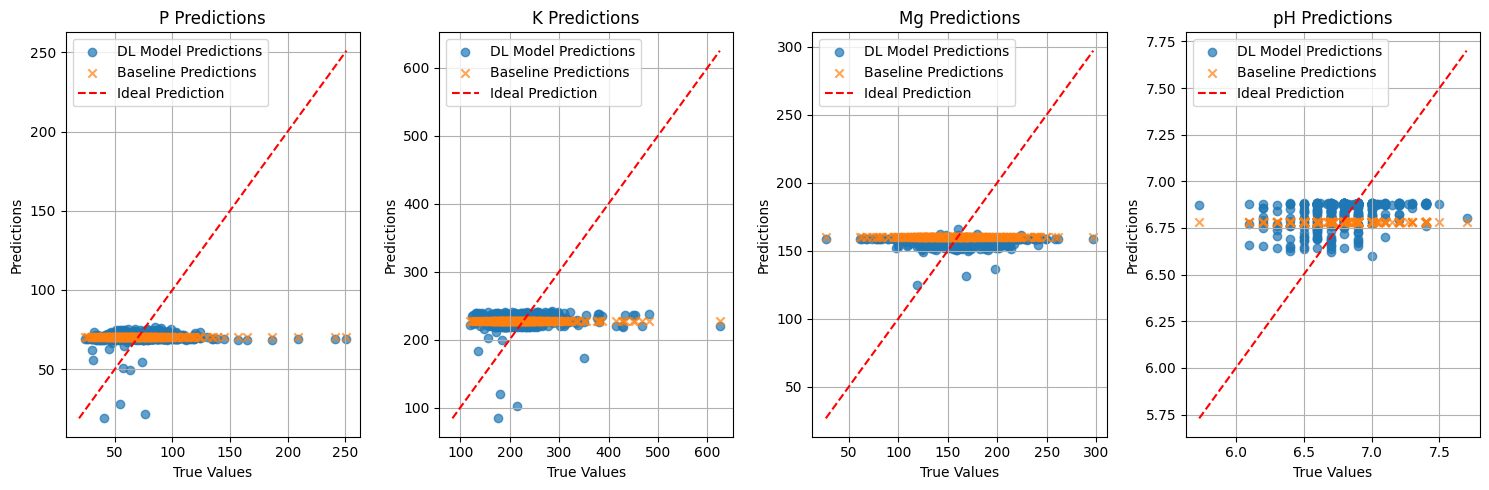

In [264]:
# Load the best model weights for the deep learning model
model.load_state_dict(torch.load("best_hyperspectral_model.pth"))

# Evaluate the deep learning model
dl_y_test_pred, dl_y_test_true, dl_model_mse_targets = evaluate_dl_model(model, test_loader, scaler_y, device)

# Evaluate the baseline regressor (using the globally available y_test_true from inverse scaling test_dataset labels)
baseline_y_test_pred, baseline_mse_targets = evaluate_baseline_regressor(baseline_reg_current, X_test_filtered, y_test_true)

# Calculate and print combined results, including plotting
calculate_and_print_results(dl_model_mse_targets, baseline_mse_targets, y_test_true, dl_y_test_pred, baseline_y_test_pred)

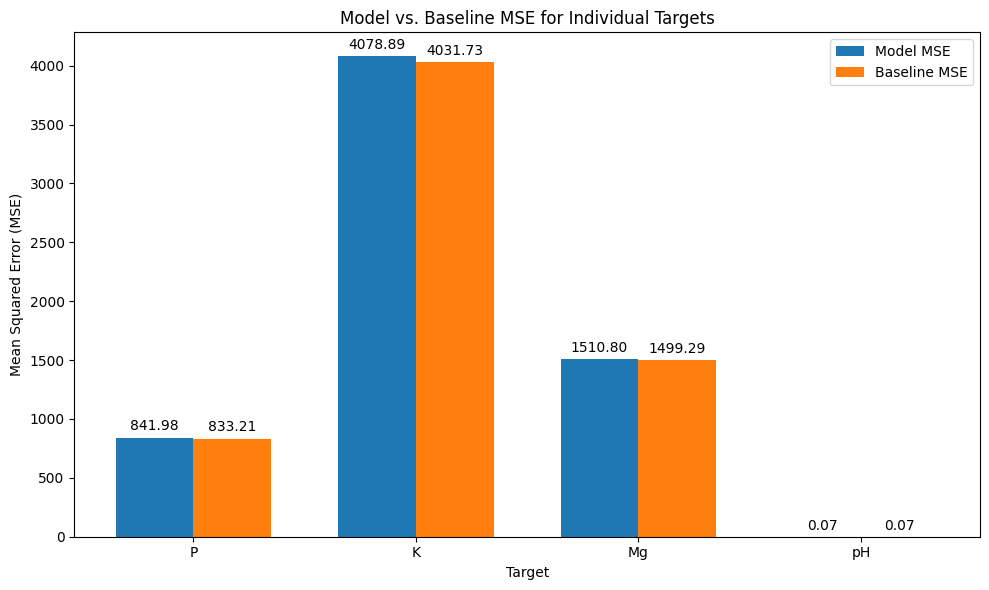

In [265]:
import matplotlib.pyplot as plt
import numpy as np

target_names = ["P", "K", "Mg", "pH"]

# Get the MSEs from the kernel state
# Assuming model_mse_targets and baseline_mse_targets are available from previous execution
model_mse_targets = np.array(model_mse_targets) # Ensure it's a numpy array for indexing
baseline_mse_targets = np.array(baseline_mse_targets) # Ensure it's a numpy array for indexing

x = np.arange(len(target_names))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, model_mse_targets, width, label='Model MSE')
rects2 = ax.bar(x + width/2, baseline_mse_targets, width, label='Baseline MSE')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Target')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('Model vs. Baseline MSE for Individual Targets')
ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

Fetching history for run: futile-dominion-1 (ID: rdqcj7jx)


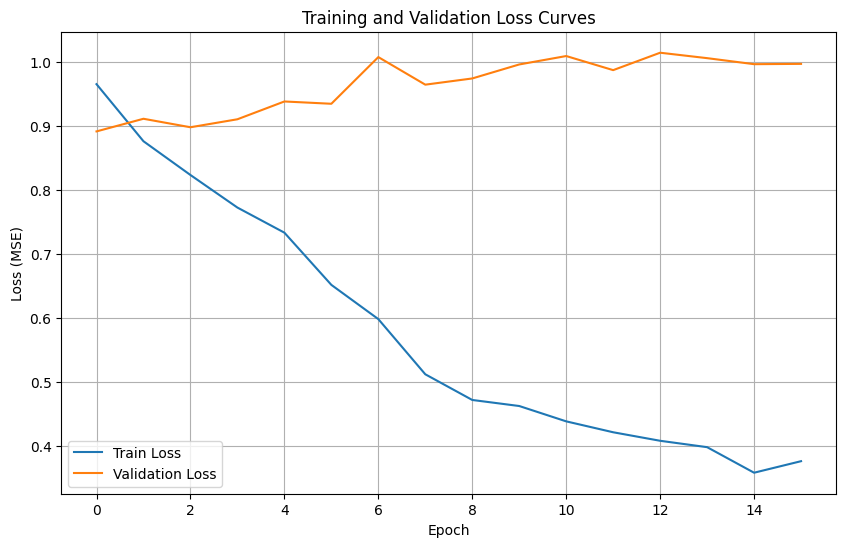

In [ ]:
import wandb
import matplotlib.pyplot as plt

# Assuming you are logged into wandb or using an anonymous account for the project.
# This will fetch the runs for the specified project.
# If you have multiple runs, you might need to specify the run ID or pick the latest one.

api = wandb.Api()
# Replace 'YOUR_ENTITY' with your Weights & Biases username or team name
# If you ran anonymously, the entity might be 'anonymous' or automatically inferred.
# We'll try to get the most recent run for the project.
runs = api.runs(path="hyperview_challenge efficientnet (pretrained encoder), rand pca", order="-created_at")

if runs:
    run = runs[0] # Get the latest run
    print(f"Fetching history for run: {run.name} (ID: {run.id})")
    history = run.history()

    plt.figure(figsize=(10, 6))
    plt.plot(history['epoch'], history['train_loss'], label='Train Loss')
    plt.plot(history['epoch'], history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No runs found for the project 'hyperview_challenge efficientnet (pretrained encoder), rand pca'.")
    print("Please ensure you are logged into wandb or the project name is correct.")